<a href="https://colab.research.google.com/github/Dimitradag/Exercise1_Advertisingdataset/blob/main/Exercise_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.sparse import hstack
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/train_NIR5Yl1.csv')
df_test  = pd.read_csv('/content/test_8i3B3FC.csv')
print(df.head())
print(df.info())

       ID Tag  Reputation  Answers  Username    Views  Upvotes
0   52664   a      3942.0      2.0    155623   7855.0     42.0
1  327662   a     26046.0     12.0     21781  55801.0   1175.0
2  468453   c      1358.0      4.0     56177   8067.0     60.0
3   96996   a       264.0      3.0    168793  27064.0      9.0
4  131465   c      4271.0      4.0    112223  13986.0     83.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330045 entries, 0 to 330044
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          330045 non-null  int64  
 1   Tag         330045 non-null  object 
 2   Reputation  330045 non-null  float64
 3   Answers     330045 non-null  float64
 4   Username    330045 non-null  int64  
 5   Views       330045 non-null  float64
 6   Upvotes     330045 non-null  float64
dtypes: float64(4), int64(2), object(1)
memory usage: 17.6+ MB
None


In [ ]:
categorical_features = ['Tag', 'Username']
numeric_features = ['Reputation', 'Answers', 'Views']

In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore')
X_cat = ohe.fit_transform(df_train[categorical_features])

In [ ]:
X_num = df_train[numeric_features].fillna(0).values

In [ ]:
X = hstack([X_cat, X_num])
y = df_train['Upvotes'].values

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_val)

In [ ]:
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 11955396.799100572
RMSE: 3457.657704154732


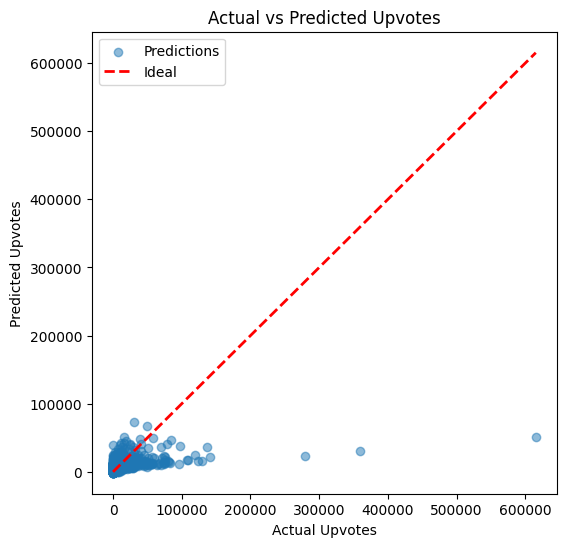

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.5, label="Predictions")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', linewidth=2, label="Ideal")
plt.xlabel("Actual Upvotes")
plt.ylabel("Predicted Upvotes")
plt.title("Actual vs Predicted Upvotes")
plt.legend()
plt.show()